# Scheduling simulator

## Descrição dos experimentos

São conduzidos três experimentos comparativos envolvendo os algoritmos FCFS, SJF não-preemptivo, SJF preemptivo, Prioridade e Round Robin, avaliados segundo as seguintes métricas: turnaround médio, tempo médio de espera, tempo médio de resposta e taxa de utilização da CPU.

1. Workload simples (`inputs/workload_simple.json`) — composto por 5 processos com um único burst de CPU cada, sem definição de quantum e sem custo de troca de contexto. Tem caráter de validação inicial, permitindo evidenciar de forma mais nítida as diferenças entre os algoritmos, sem interferência de operações de E/S.
2. Workload realista (`inputs/workload.json`) — composto por 27 processos com bursts de CPU e E/S, prioridades distintas, `quantum = 5` e `context_switch_cost = 1`. Tem por objetivo avaliar o comportamento dos algoritmos sob uma carga mais representativa de cenários reais, contemplando o impacto da troca de contexto sobre a utilização da CPU.
3. Análise de sensibilidade do Round Robin ao quantum — valores de quantum variando entre 1 e 60, executada sobre os 10 workloads e calculando a média por quantum.

Para (1, 2), cada experimento são produzidos o diagrama de Gantt referente a cada algoritmo, gráficos de barras comparando as métricas e tabelas em formato markdown contendo os valores obtidos e os algoritmos vencedores em cada métrica.

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

from models.process.workload import Workload
from shared.constants import COMPARISON_METRICS
from shared.evaluation import pick_winners
from shared.runner import run_simulation
from shared.parser import parse_input
from shared.plots import plot_gantt, plot_metric_bars
from shared.reporter import aggregate_reports
from shared.reporter import print_comparison as print_comparison_shared


In [10]:
def run_simulation_notebook(path):
    workload = parse_input(path)

    results, gantts, reports = run_simulation(workload)

    print_comparison_shared(reports, pick_winners(reports))

    return results, gantts, reports


In [11]:
results, gantts, reports = run_simulation_notebook("inputs/workload_simple.json")

Comparison
algorithm	avg_turnaround	avg_waiting	avg_response	cpu_utilization
FCFS	9.0000	4.4000	4.4000	1.0000
SJF	8.8000	4.2000	4.2000	1.0000
SJF (preemptive)	7.8000	3.2000	1.8000	1.0000
Priority	9.0000	4.4000	4.4000	1.0000
Round Robin	10.2000	5.6000	0.6000	1.0000

Winner per metric
  avg_turnaround: SJF (preemptive)
  avg_waiting: SJF (preemptive)
  avg_response: Round Robin
  cpu_utilization: FCFS


In [12]:
def print_comparison(results, gantts, reports):
    for result, gantt in zip(results, gantts):
        fig, ax = plt.subplots(figsize=(10, 10))
        plot_gantt(result, ax=ax, gantt=gantt)
        fig.tight_layout()
        plt.show()
    
    for metric in COMPARISON_METRICS:
        fig, ax = plt.subplots(figsize=(8, 4))
        plot_metric_bars(reports, metric, ax=ax)
        fig.tight_layout()
        plt.show()

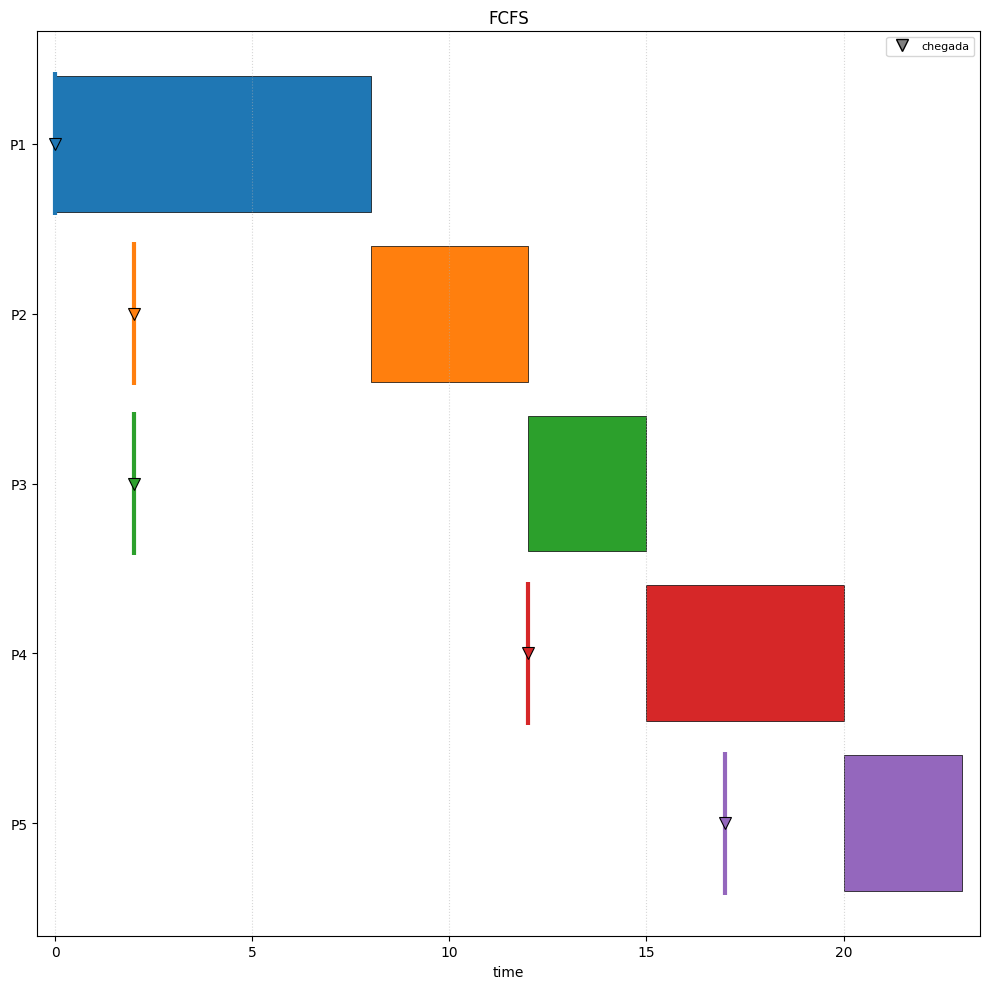

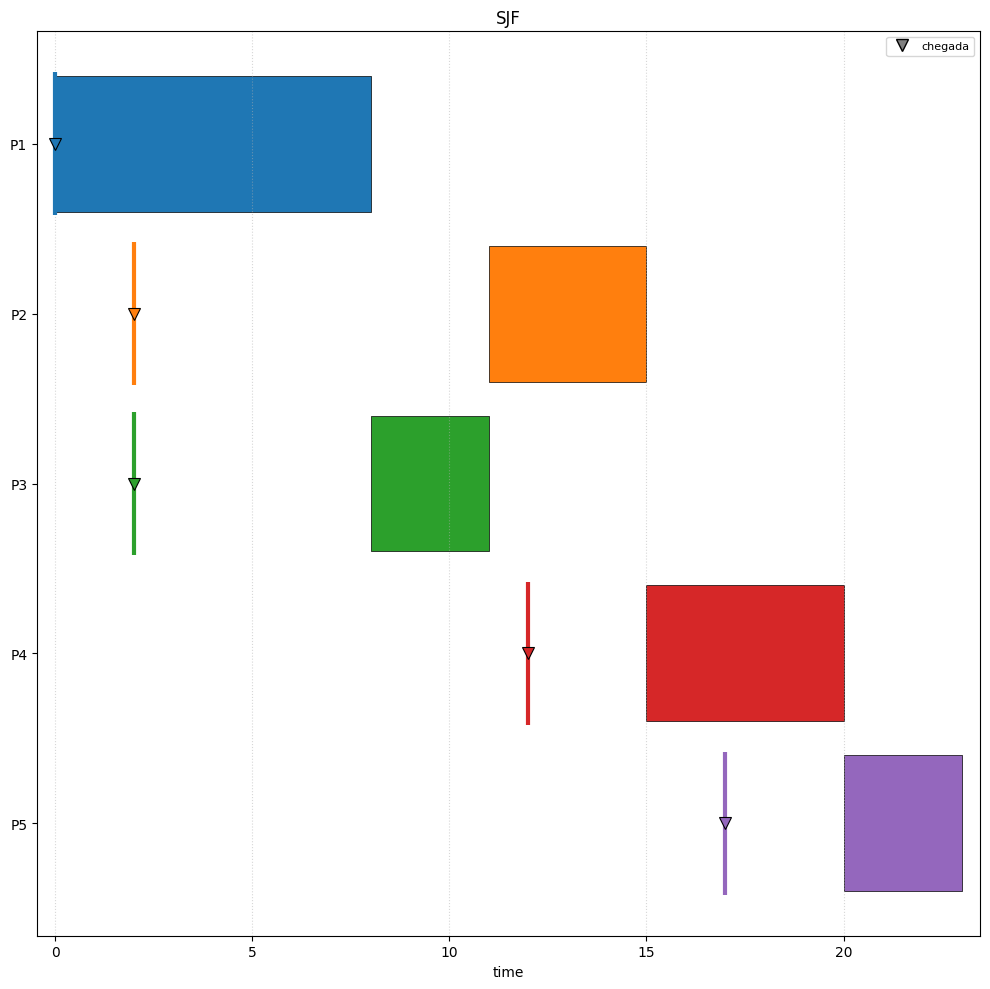

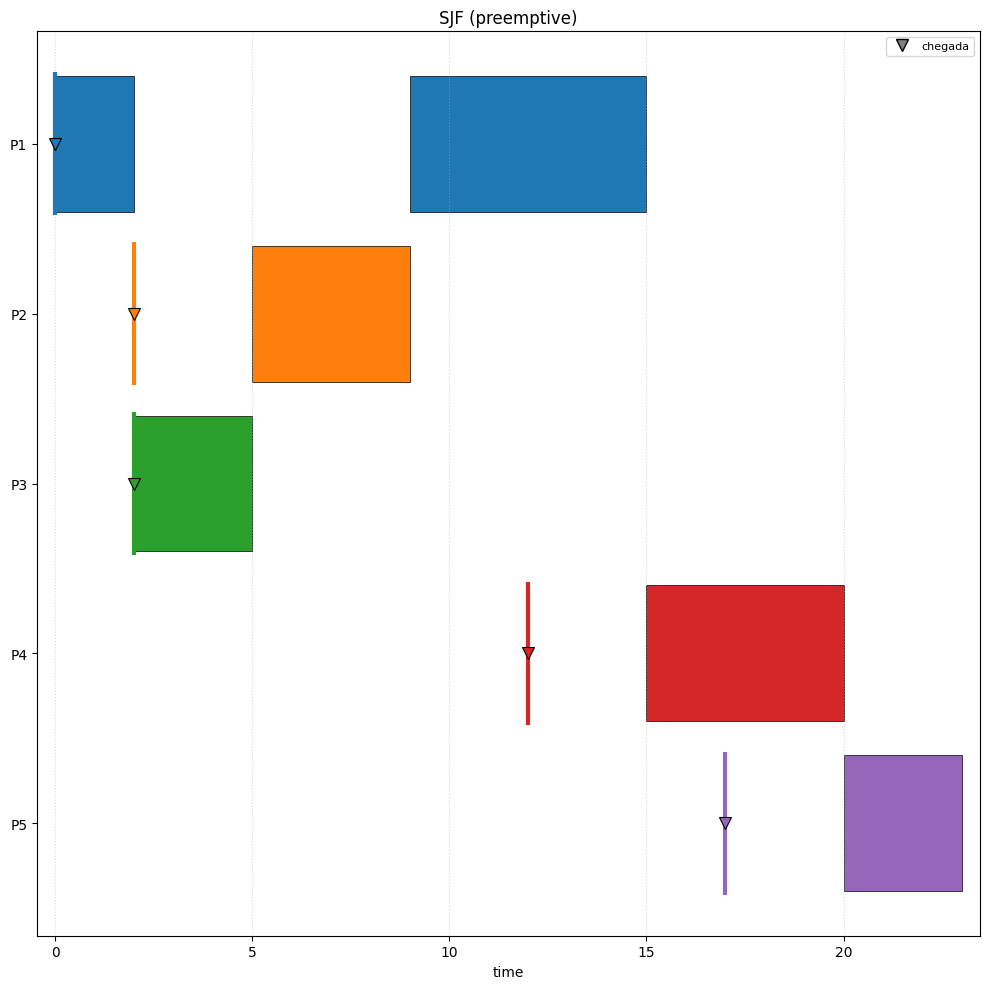

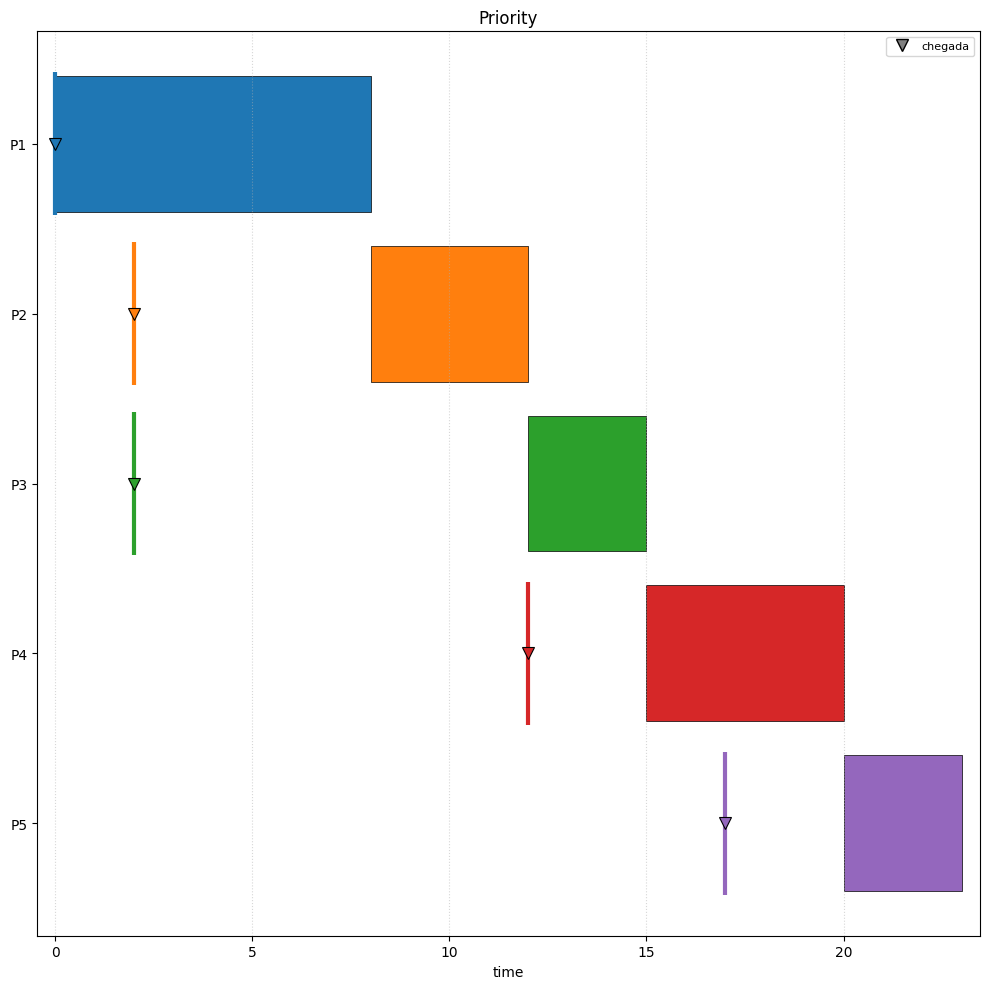

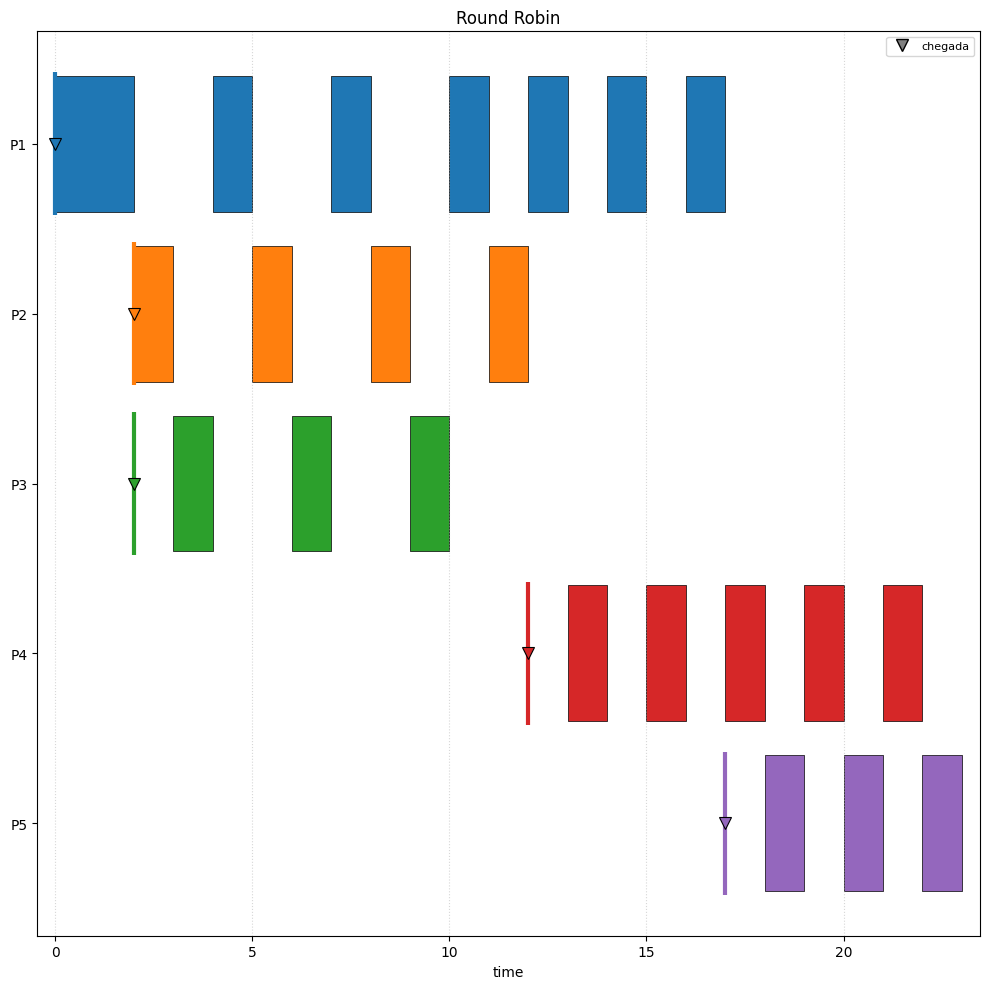

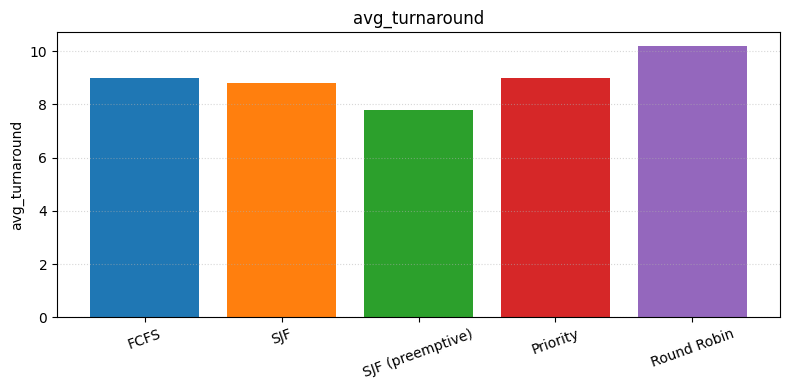

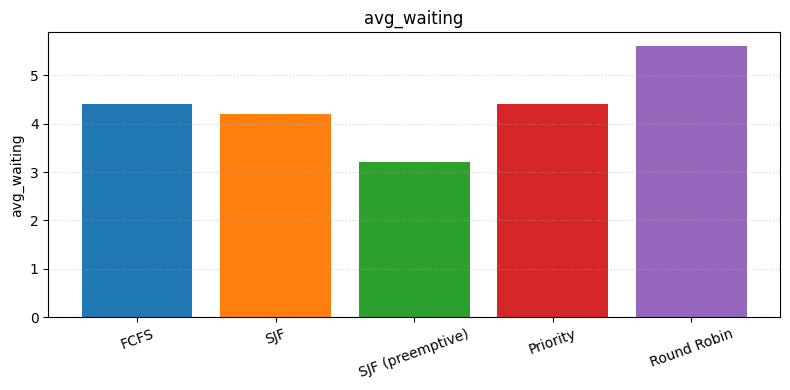

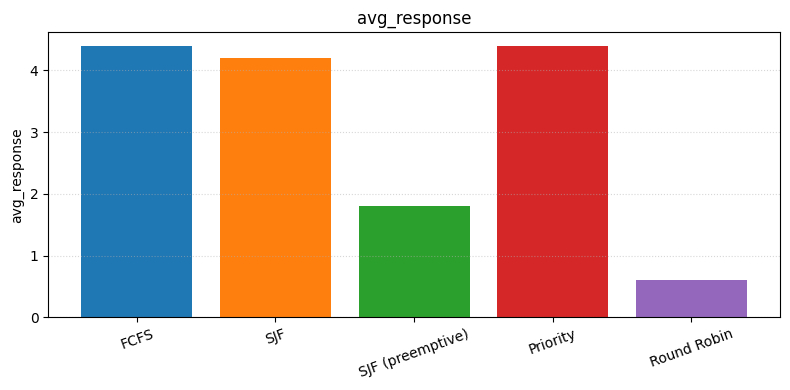

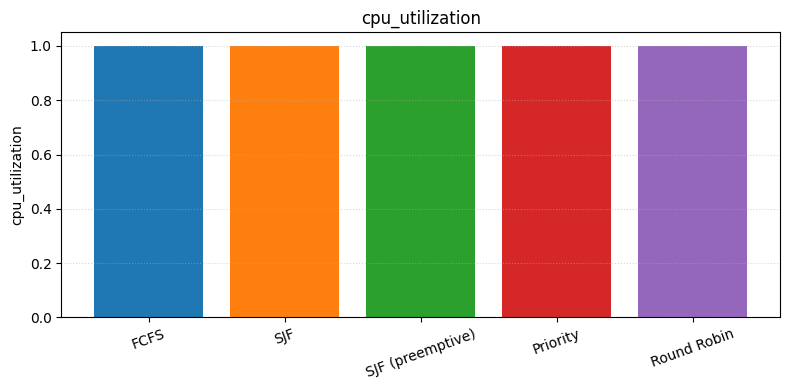

In [13]:
print_comparison(results, gantts, reports)

## Comparação entre algoritmos

Métricas médias (workload padrão do `inputs/workload_simple.json`).

### Mesmos números em tabela Markdown

| Algoritmo | Avg. turnaround | Avg. waiting | Avg. response | CPU utilization |
| :-- | --: | --: | --: | --: |
| FCFS | 9.0000 | 4.4000 | 4.4000 | 1.0000 |
| SJF | 8.8000 | 4.2000 | 4.2000 | 1.0000 |
| SJF (preemptive) | 7.8000 | 3.2000 | 1.8000 | 1.0000 |
| Priority | 9.0000 | 4.4000 | 4.4000 | 1.0000 |
| Round Robin | 10.2000 | 5.6000 | 0.6000 | 1.0000 |

### Melhor por métrica

| Métrica | Vencedor |
| :-- | :-- |
| `avg_turnaround` | SJF (preemptive) |
| `avg_waiting` | SJF (preemptive) |
| `avg_response` | Round Robin |
| `cpu_utilization` | FCFS |


In [14]:
results, gantts, reports = run_simulation_notebook("inputs/workload.json")

Comparison
algorithm	avg_turnaround	avg_waiting	avg_response	cpu_utilization
FCFS	71.2222	65.7778	37.5926	0.7143
SJF	58.2593	52.8148	41.3704	0.7143
SJF (preemptive)	58.1481	52.7037	40.3333	0.7051
Priority	65.0370	59.5926	52.7037	0.7097
Round Robin	77.6296	72.1852	35.7778	0.6962

Winner per metric
  avg_turnaround: SJF (preemptive)
  avg_waiting: SJF (preemptive)
  avg_response: Round Robin
  cpu_utilization: FCFS


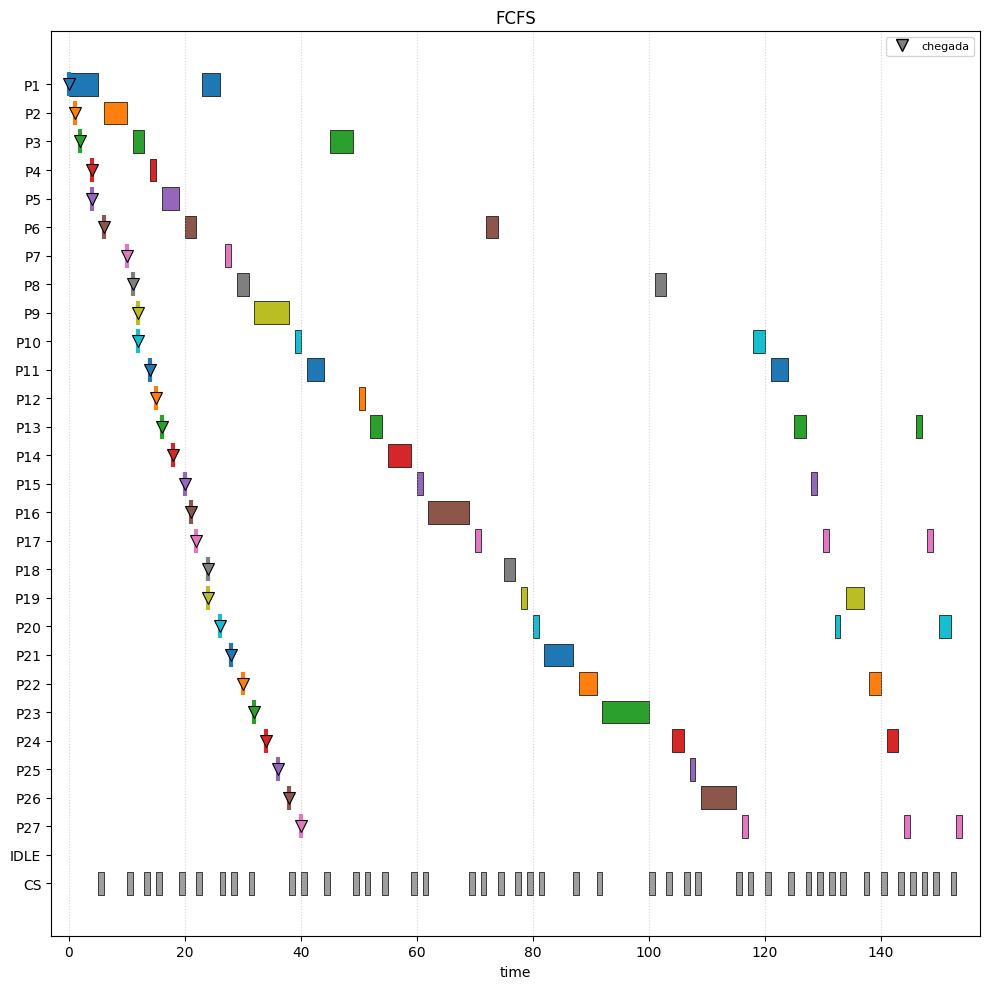

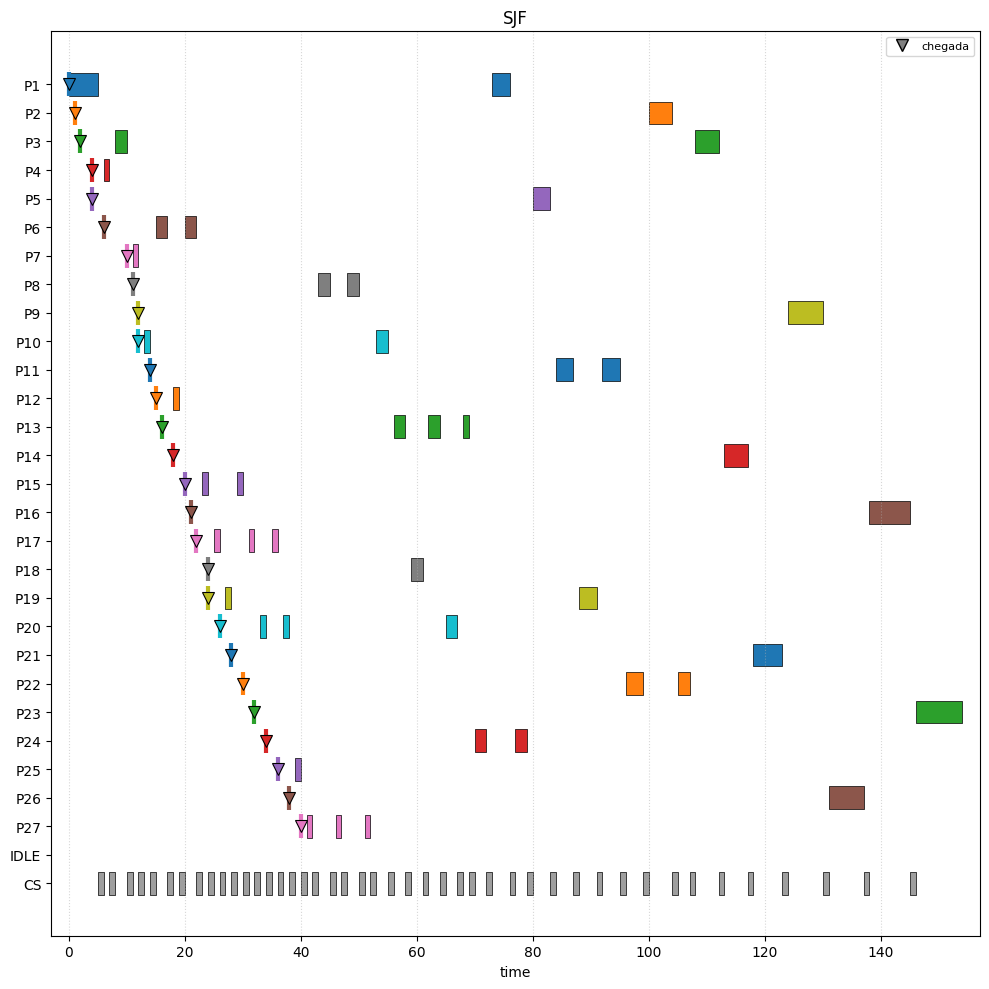

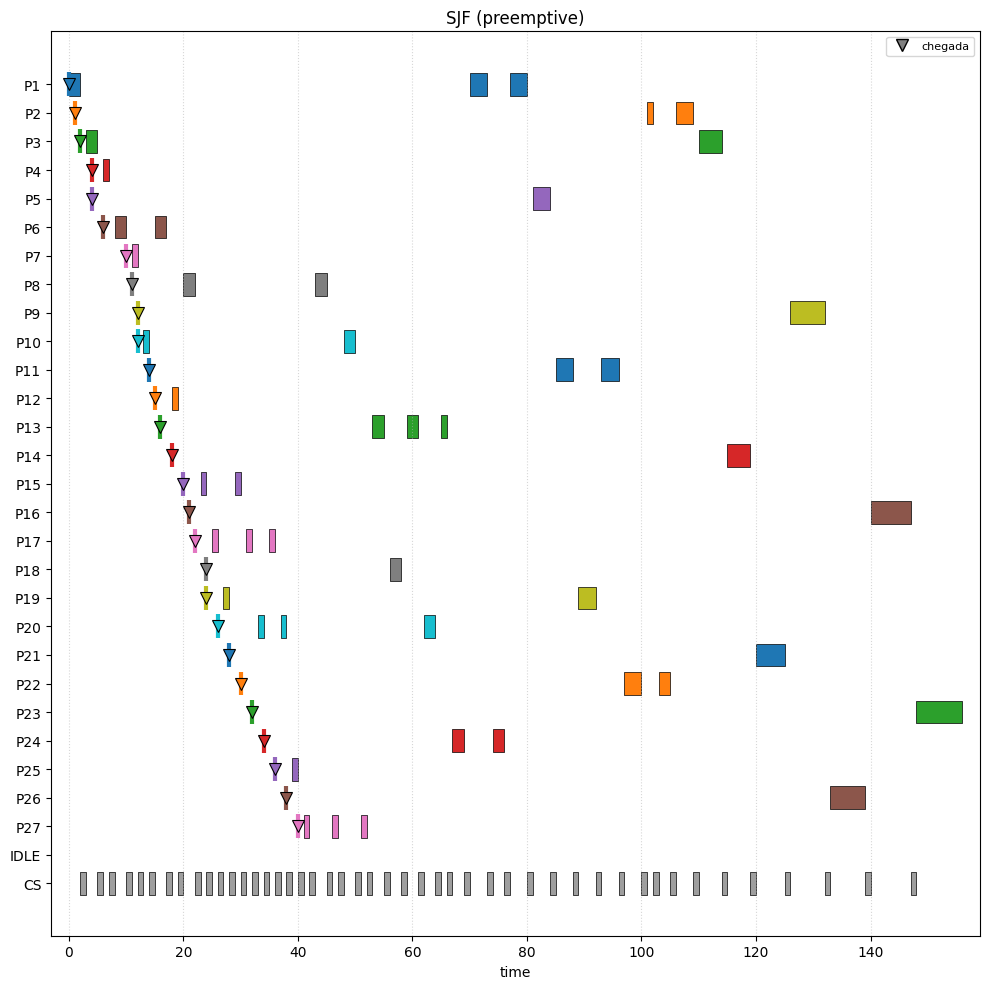

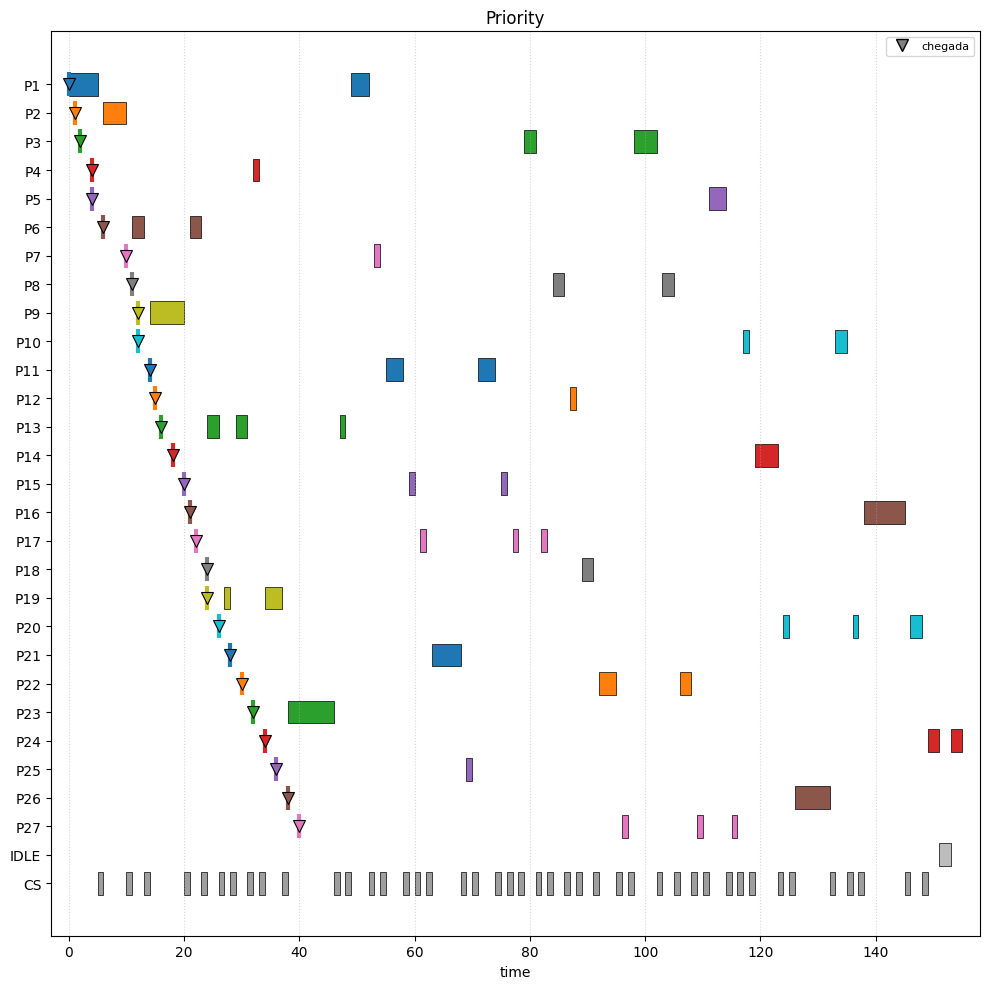

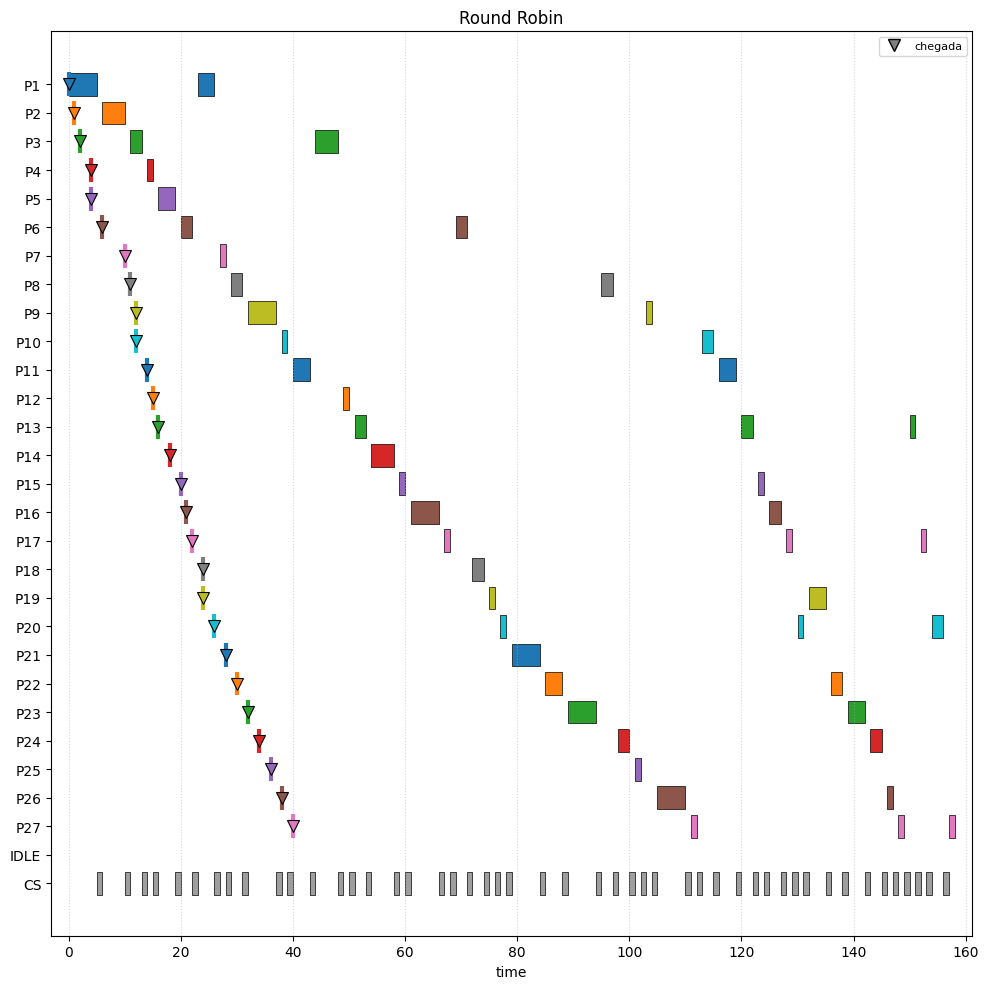

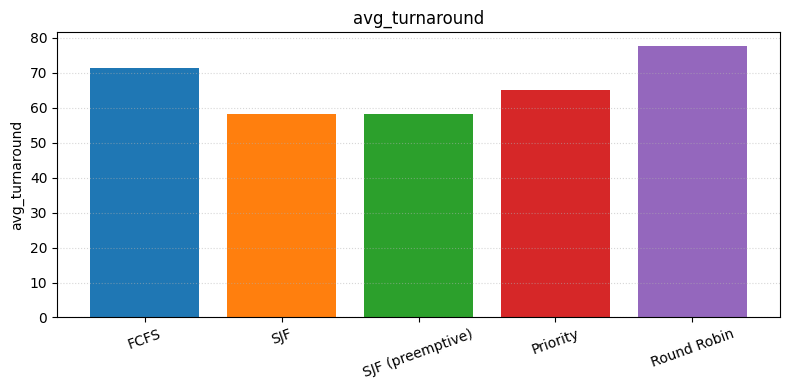

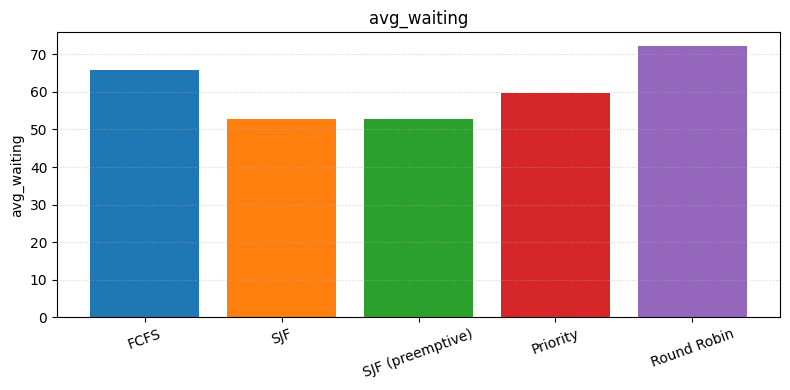

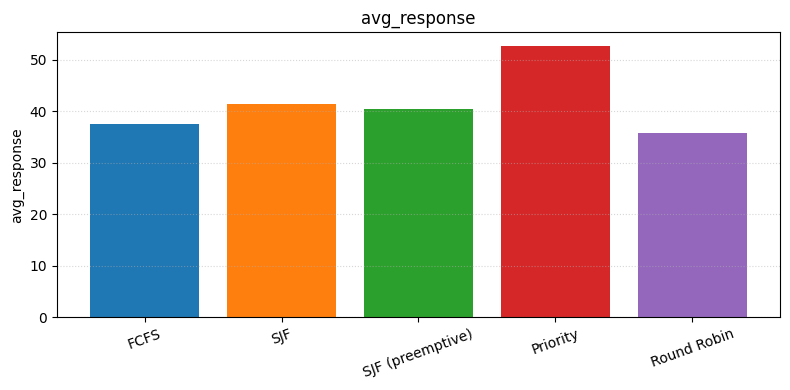

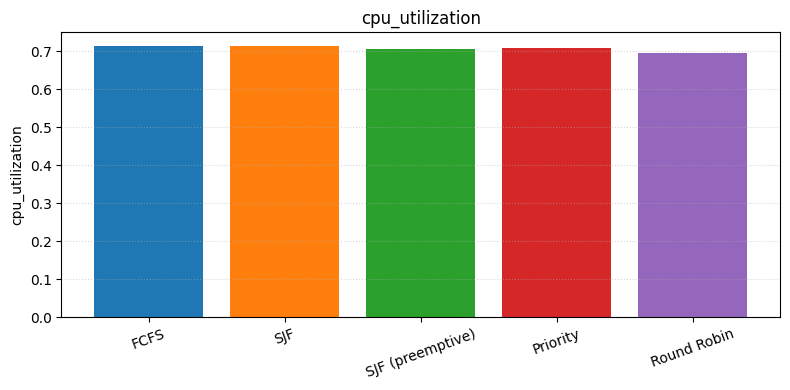

In [15]:
print_comparison(results, gantts, reports)


## Comparação entre algoritmos

Métricas médias (workload padrão do `inputs/workload.json`).

### Mesmos números em tabela Markdown

| Algoritmo | Avg. turnaround | Avg. waiting | Avg. response | CPU utilization |
| :-- | --: | --: | --: | --: |
| FCFS | 71.2222 | 65.7778 | 37.5926 | 0.7143 |
| SJF | 58.2593 | 52.8148 | 41.3704 | 0.7143 |
| SJF (preemptive) | 58.1481 | 52.7037 | 40.3333 | 0.7051 |
| Priority | 65.0370 | 59.5926 | 52.7037 | 0.7097 |
| Round Robin | 77.6296 | 72.1852 | 35.7778 | 0.6962 |

### Melhor por métrica

| Métrica | Vencedor |
| :-- | :-- |
| `avg_turnaround` | SJF (preemptive) |
| `avg_waiting` | SJF (preemptive) |
| `avg_response` | Round Robin |
| `cpu_utilization` | FCFS |


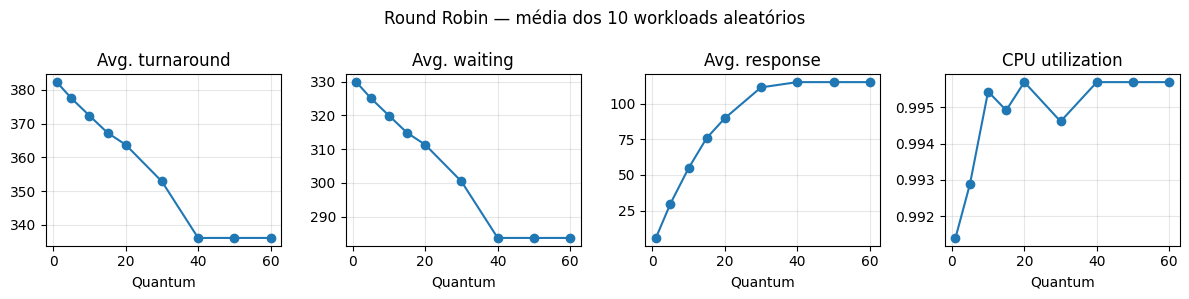

In [ ]:
WORKLOAD_RANDOM_JSON = tuple(f"inputs/workload_random_{i:02d}.json" for i in range(1, 11))
QUANTUMS = (1, 5, 10, 15, 20, 30, 40, 50)

rr_by_quantum = {}
for q in QUANTUMS:
    runs = []
    for path in WORKLOAD_RANDOM_JSON:
        base = parse_input(path)
        workload = Workload(
            base.processes,
            quantum=q,
            context_switch_cost=base.context_switch_cost,
        )
        _, _, reports = run_simulation(workload, algo="round-robin")
        runs.append(reports)
    rr_by_quantum[q] = aggregate_reports(runs)[0]

xs = list(QUANTUMS)
titles = ("Avg. turnaround", "Avg. waiting", "Avg. response", "CPU utilization")
fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharex=True)
for ax, metric, title in zip(axes, COMPARISON_METRICS, titles):
    ys = [getattr(rr_by_quantum[q], metric) for q in xs]
    ax.plot(xs, ys, marker="o")
    ax.set_title(title)
    ax.set_xlabel("Quantum")
    ax.grid(True, alpha=0.3)
fig.suptitle("Round Robin — média dos 10 workloads aleatórios")
fig.tight_layout()
plt.show()

Round Robin apenas; quantums 1, 5, 10, ... 40, 50; média dos `workload_random_01` … `_10`.

## Conclusão

Os resultados obtidos nos dois workloads avaliados indicam que o algoritmo SJF preemptivo apresentou o melhor desempenho nas métricas de turnaround médio e tempo médio de espera. Round Robin obteve o menor tempo médio de resposta. Esse ganho em responsividade do Round Robin foi acompanhado, no entanto, por uma redução nas demais métricas, atribuível ao custo de troca de contexto. O algoritmo FCFS apresenta a maior taxa de utilização da CPU.

No experimento de sensibilidade do Round Robin ao quantum, observou-se uma relação inversa entre o tamanho do quantum e o tempo médio de resposta: quantums menores favorecem a responsividade, em decorrência da maior frequência de alternância entre processos, mas implicam em aumento do turnaround médio e em queda da utilização da CPU, dado o overhead adicional de troca de contexto. Quantums maiores, por sua vez, aproximam o comportamento do Round Robin ao do FCFS, melhorando o turnaround e a utilização, em detrimento do tempo de resposta.